In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsOneClassifier
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
file_path

'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv'

In [3]:
df = pd.read_csv(file_path)
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [4]:
df.shape

(2111, 17)

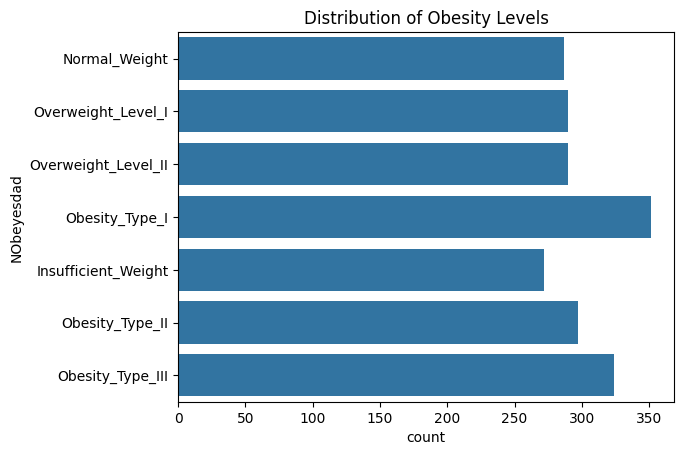

In [9]:
# Exploratory Data Analysis
# Distribution of target variable
# turns out that the dataset is fairly balanced and doesn't require any special attention in terms of biased training
sns.countplot(y = 'NObeyesdad', data = df)
plt.title('Distribution of Obesity Levels')
plt.show()

## Check if there is any null value in the dataset

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [11]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [18]:
df.isnull().sum()

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

## Preprocessing the data

In [32]:
# feature scaling
# standardizing continuous numerical features (numerical features are those columns that shows in describe function
# lets extract column names that contain only float value
continuous_columns = df.select_dtypes(include = ['float64']).columns.tolist()
# use standard scaler to normalize those numeric values
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[continuous_columns])
# converting to a dataframe
# get_feature_names_out() function is also workable
scaled_df = pd.DataFrame(scaled_features, columns = continuous_columns)
# combining with the original dataset
scaled_data = pd.concat([df.drop(columns = continuous_columns), scaled_df], axis = 1)
scaled_data

,Gender,family_history_with_overweight,FAVC,CAEC,SMOKE,SCC,CALC,MTRANS,NObeyesdad,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
0,Female,yes,no,Sometimes,no,no,no,Public_Transportation,Normal_Weight,-0.522124,-0.875589,-0.862558,-0.785019,0.404153,-0.013073,-1.188039,0.561997
1,Female,yes,no,Sometimes,yes,yes,Sometimes,Public_Transportation,Normal_Weight,-0.522124,-1.947599,-1.168077,1.088342,0.404153,1.618759,2.339750,-1.080625
2,Male,yes,no,Sometimes,no,no,Frequently,Public_Transportation,Normal_Weight,-0.206889,1.054029,-0.366090,-0.785019,0.404153,-0.013073,1.163820,0.561997
3,Male,no,no,Sometimes,no,no,Frequently,Walking,Overweight_Level_I,0.423582,1.054029,0.015808,1.088342,0.404153,-0.013073,1.163820,-1.080625
4,Male,no,no,Sometimes,no,no,Sometimes,Public_Transportation,Overweight_Level_II,-0.364507,0.839627,0.122740,-0.785019,-2.167023,-0.013073,-1.188039,-1.080625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation,Obesity_Type_III,-0.525774,0.097045,1.711763,1.088342,0.404153,-0.456705,0.783135,0.407996
2107,Female,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation,Obesity_Type_III,-0.367195,0.502844,1.800914,1.088342,0.404153,-0.004702,0.389341,-0.096251
2108,Female,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation,Obesity_Type_III,-0.281909,0.541672,1.798868,1.088342,0.404153,0.075361,0.474971,-0.019018
2109,Female,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation,Obesity_Type_III,0.007776,0.404927,1.785780,1.088342,0.404153,1.377801,0.151471,-0.117991


## One-hot Encoding

In [39]:
# convert categorical variables into numerical format using one-hot encoding
# identifying categorical columns
categorical_columns = scaled_data.select_dtypes(include = ['object']).columns.tolist()
categorical_columns.remove('NObeyesdad')
# Applying one-hot encoding
# drop = 'first' reduce redundacy (by removing the category that dependent on others)
# sparse_output = False told OneHotEncoder to not show the default sparse matrix (less readable)
encoder = OneHotEncoder(sparse_output = False, drop = 'first')
encoded_features = encoder.fit_transform(scaled_data[categorical_columns])
# convert to a dataframe
encoded_df = pd.DataFrame(encoded_features, columns = encoder.get_feature_names_out(categorical_columns))
# combining with the original dataset
preprocessed_data = pd.concat([scaled_data.drop(columns = categorical_columns), encoded_df], axis = 1)
preprocessed_data

,NObeyesdad,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender_Male,...,CAEC_no,SMOKE_yes,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,Normal_Weight,-0.522124,-0.875589,-0.862558,-0.785019,0.404153,-0.013073,-1.188039,0.561997,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,Normal_Weight,-0.522124,-1.947599,-1.168077,1.088342,0.404153,1.618759,2.339750,-1.080625,0.0,...,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,Normal_Weight,-0.206889,1.054029,-0.366090,-0.785019,0.404153,-0.013073,1.163820,0.561997,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,Overweight_Level_I,0.423582,1.054029,0.015808,1.088342,0.404153,-0.013073,1.163820,-1.080625,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,Overweight_Level_II,-0.364507,0.839627,0.122740,-0.785019,-2.167023,-0.013073,-1.188039,-1.080625,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Obesity_Type_III,-0.525774,0.097045,1.711763,1.088342,0.404153,-0.456705,0.783135,0.407996,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2107,Obesity_Type_III,-0.367195,0.502844,1.800914,1.088342,0.404153,-0.004702,0.389341,-0.096251,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2108,Obesity_Type_III,-0.281909,0.541672,1.798868,1.088342,0.404153,0.075361,0.474971,-0.019018,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2109,Obesity_Type_III,0.007776,0.404927,1.785780,1.088342,0.404153,1.377801,0.151471,-0.117991,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


## Encode the target variable

In [40]:
preprocessed_data['NObeyesdad'] = preprocessed_data['NObeyesdad'].astype('category').cat.codes
preprocessed_data.head()

,NObeyesdad,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender_Male,...,CAEC_no,SMOKE_yes,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,1,-0.522124,-0.875589,-0.862558,-0.785019,0.404153,-0.013073,-1.188039,0.561997,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,1,-0.522124,-1.947599,-1.168077,1.088342,0.404153,1.618759,2.339750,-1.080625,0.0,...,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,1,-0.206889,1.054029,-0.366090,-0.785019,0.404153,-0.013073,1.163820,0.561997,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,5,0.423582,1.054029,0.015808,1.088342,0.404153,-0.013073,1.163820,-1.080625,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,6,-0.364507,0.839627,0.122740,-0.785019,-2.167023,-0.013073,-1.188039,-1.080625,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


## Separate the input and target data

In [41]:
x = preprocessed_data.drop('NObeyesdad', axis = 1)
y = preprocessed_data['NObeyesdad']

## Model training and evaluation

In [43]:
# splitting data
# keep the same class distribution in training set and testing set by using stratify
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42, stratify = y)

## Logistic Regression with OvA

In [45]:
# training logistic regression model using One vs All (default)
model_ova = LogisticRegression(multi_class = 'ovr', max_iter = 1000)
model_ova.fit(x_train, y_train)

LogisticRegression(max_iter=1000, multi_class='ovr')

In [46]:
# predictions
y_pred_ova = model_ova.predict(x_test)
print('OvA Strategy')
print(f'Accuracy: {np.round(100 * accuracy_score(y_test, y_pred_ova), 2)}%')

OvA Strategy
Accuracy: 76.12%


## Logistic Regression with OvO

In [47]:
# training logistic regression model using One-vs-One
model_ovo = OneVsOneClassifier(LogisticRegression(max_iter = 1000))
model_ovo.fit(x_train, y_train)

OneVsOneClassifier(estimator=LogisticRegression(max_iter=1000))

In [48]:
# prediction
y_pred_ovo = model_ovo.predict(x_test)
print('OvO Strategy')
print(f'Accuracy: {np.round(100 * accuracy_score(y_test, y_pred_ovo), 2)}%')

OvO Strategy
Accuracy: 92.2%


## Practice

In [54]:
# try different train/test dataset size and see if it affect the model performance (ova)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.1, random_state = 42)
model_ova.fit(x_train, y_train)
y_pred_ova = model_ova.predict(x_test)
print('Accuracy score with 10% testing dataset using ova strategy: ', 100 * np.round(accuracy_score(y_test, y_pred_ova), 2), '%')
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)
model_ova.fit(x_train, y_train)
y_pred_ova = model_ova.predict(x_test)
print('Accuracy score with 30% testing dataset using ova strategy: ', 100 * np.round(accuracy_score(y_test, y_pred_ova), 2), '%')
# try different train/test dataset size and see if it affect the model performance (ovo)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.1, random_state = 42)
model_ovo.fit(x_train, y_train)
y_pred_ovo = model_ovo.predict(x_test)
print('Accuracy score with 10% testing dataset using ovo strategy: ', 100 * np.round(accuracy_score(y_test, y_pred_ovo), 2), '%')
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)
model_ovo.fit(x_train, y_train)
y_pred_ovo = model_ovo.predict(x_test)
print('Accuracy score with 30% testing dataset using ovo strategy: ', 100 * np.round(accuracy_score(y_test, y_pred_ovo), 2), '%')

Accuracy score with 10% testing dataset using ova strategy:  73.0 %
Accuracy score with 30% testing dataset using ova strategy:  75.0 %
Accuracy score with 10% testing dataset using ovo strategy:  92.0 %
Accuracy score with 30% testing dataset using ovo strategy:  93.0 %


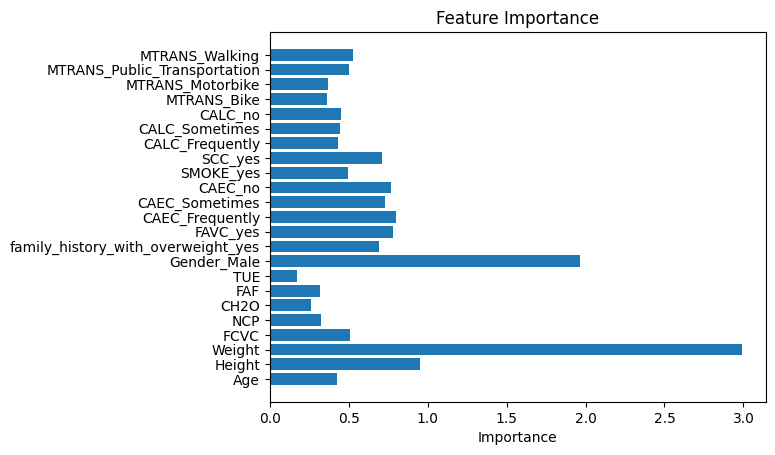

In [57]:
# plot a bar chart of feature importance using the coefficients from the OvA logistic regression model
feature_importance = np.mean(np.abs(model_ova.coef_), axis = 0)
plt.barh(x.columns, feature_importance)
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.show()

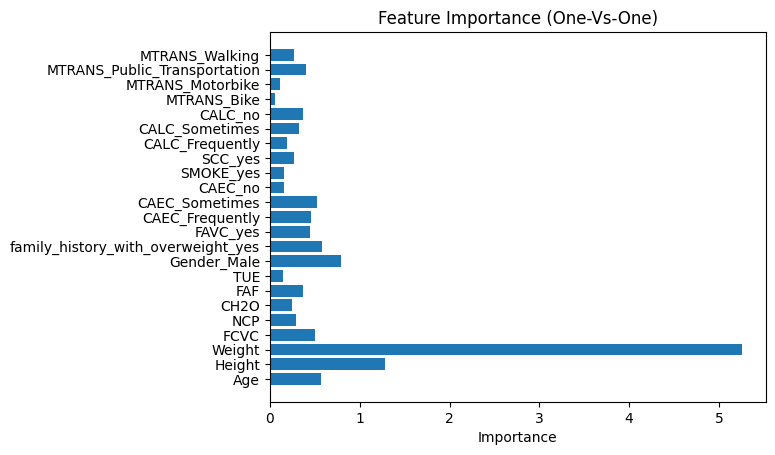

In [59]:
# plot a bar chart of feature importance using the coefficients from the OvO logistic regression model
coefs = np.array([est.coef_[0] for est in model_ovo.estimators_])
feature_importance = np.mean(np.abs(coefs), axis = 0)
plt.barh(x.columns, feature_importance)
plt.title('Feature Importance (One-Vs-One)')
plt.xlabel('Importance')
plt.show()

In [83]:
# write a function obesity_risk_pipeline to automate the entire pipeline
def obesity_risk_pipeline(data_path, test_size = 0.2):
    
    # read csv file into dataframe
    df = pd.read_csv(data_path)
    
    # separate the categorical columns and numerical columns
    # for categorical columns, use one hot encoder to turn them into numerical values
    categorical_columns = df.select_dtypes(include = ['object']).columns.tolist()
    categorical_columns.remove('NObeyesdad')
    # sparse output set to be False so that the output can be readable and is a dense numpy array
    # drop first to avoid output the dummy row
    encoder = OneHotEncoder(sparse_output = False, drop = 'first')
    encoded_features = encoder.fit_transform(df[categorical_columns])
    feature_name = encoder.get_feature_names_out(categorical_columns)
    categorical_data = pd.DataFrame(encoded_features, columns = feature_name)
    
    # use of StandardScaler to normalize the numerical data so that every feature is equal of its size
    numerical_columns = df.select_dtypes(include = ['float64']).columns.tolist()
    scaler = StandardScaler()
    norm_features = scaler.fit_transform(df[numerical_columns])
    norm_data = pd.DataFrame(norm_features, columns = numerical_columns)

    # combine target column, categorical columns, and numerical columns into the dataframe
    preprocessed_df = pd.concat([df['NObeyesdad'], categorical_data, norm_data], axis = 1)

    # separate target values from feature values. Also, set the testing dataset as 20% of total dataset size
    x = preprocessed_df.drop('NObeyesdad', axis = 1)
    y = preprocessed_df['NObeyesdad']
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = test_size, random_state = 42)

    # create classifier model (logistic regression) with OvA strategy
    model_ova = LogisticRegression(multi_class = 'ovr', max_iter = 1000)
    model_ova.fit(x_train, y_train)
    y_pred = model_ova.predict(x_test)
    print(f'Accuracy of using Logistic Regression Model with OvA is: {np.round(100 * accuracy_score(y_test, y_pred), 2)}%')

    # create classifier model (logistic regression) with OvO strategy
    # since OvA is default setting in Logistic Regression and OvO is not, use OneVsOneClassifier instead from sklearn.multiclass library
    model_ovo = OneVsOneClassifier(LogisticRegression(max_iter = 1000))
    model_ovo.fit(x_train, y_train)
    y_pred = model_ovo.predict(x_test)
    print(f'Accuracy of using Logistic Regression Model with OvO is: {np.round(100 * accuracy_score(y_test, y_pred), 2)}%')

file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
obesity_risk_pipeline(file_path, 0.3)

Accuracy of using Logistic Regression Model with OvA is: 75.39%
Accuracy of using Logistic Regression Model with OvO is: 92.74%
